In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("PMFBY statistics.csv")

# 🔥 Strong cleaning (handles everything properly)
df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)  # replace EVERYTHING non-alphanumeric
    .str.replace("__", "_")
    .str.strip("_")
)

print("✅ Cleaned Columns:\n", df.columns.tolist())

# Drop useless columns if present
drop_cols = [
    "district_updatedat",
    "district_nextlevelparams",
    "district_districtcode",
    "district_scheme"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Target
target = "district_suminsured_lac"

# Drop NA
df = df.dropna()

print("✅ Shape:", df.shape)
df.head()

✅ Cleaned Columns:
 ['year', 'season', 'scheme', 'state', 'district_farmercount', 'district_application_loanee', 'district_nonloanee', 'district_areainsured_th_ha', 'district_suminsured_lac', 'district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_gender_male', 'district_gender_female', 'district_gender_transgender', 'district_category_sc', 'district_category_st', 'district_category_obc', 'district_category_gen', 'district_type_marginal', 'district_type_small', 'district_type_other', 'district_iucount', 'district_updatedat', 'district_districtname', 'district_districtcode', 'district_scheme', 'district_grosspremium_lac', 'district_nextlevelparams']
✅ Shape: (3570, 25)


,year,season,scheme,state,district_farmercount,district_application_loanee,district_nonloanee,district_areainsured_th_ha,district_suminsured_lac,district_farmershare_lac,...,district_category_sc,district_category_st,district_category_obc,district_category_gen,district_type_marginal,district_type_small,district_type_other,district_iucount,district_districtname,district_grosspremium_lac
0,2018,Kharif,WBCIS,ANDHRA PRADESH,530381,554393.0,260,898.02,427253.53,8589.30,...,7.15,3.58,54.00,35.27,15.21,64.60,20.19,63,Anantapur,54860.04
1,2018,Kharif,WBCIS,ANDHRA PRADESH,32478,20405.0,13573,27.45,19028.48,666.72,...,5.09,1.85,34.30,58.76,12.79,75.58,11.63,57,Chittoor,1522.76
2,2018,Kharif,WBCIS,ANDHRA PRADESH,80,92.0,0,0.20,121.44,6.07,...,0.00,0.00,8.70,91.30,8.70,23.91,67.39,18,East Godavari,9.71
3,2018,Kharif,WBCIS,ANDHRA PRADESH,10077,10171.0,821,8.24,11767.03,588.35,...,3.27,3.05,48.28,45.40,12.62,74.09,13.29,53,Guntur,986.99
4,2018,Kharif,WBCIS,ANDHRA PRADESH,97,98.0,0,0.12,164.42,8.22,...,2.04,0.00,47.96,50.00,40.82,44.90,14.28,6,Krishna,16.44


In [2]:
# 🔥 Automatically detect columns instead of hardcoding wrong names

print("\n🔍 Available columns:\n", df.columns.tolist())

# Target
target = "district_suminsured_lac"

# 🔥 Select features dynamically (safe approach)
features = [col for col in df.columns if col != target]

# Optional: remove obvious useless columns if still present
useless_keywords = ["date", "code", "id"]
features = [col for col in features if not any(k in col for k in useless_keywords)]

print("\n✅ Selected Features:\n", features)

# Keep only required
df = df[features + [target]].copy()

# 🔥 Detect categorical automatically
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    df[col] = df[col].astype("category")

print("\n✅ Categorical Columns:", categorical_cols)

# Split
X = df.drop(columns=[target])
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n✅ Train shape:", X_train.shape)
print("✅ Validation shape:", X_val.shape)


🔍 Available columns:
 ['year', 'season', 'scheme', 'state', 'district_farmercount', 'district_application_loanee', 'district_nonloanee', 'district_areainsured_th_ha', 'district_suminsured_lac', 'district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_gender_male', 'district_gender_female', 'district_gender_transgender', 'district_category_sc', 'district_category_st', 'district_category_obc', 'district_category_gen', 'district_type_marginal', 'district_type_small', 'district_type_other', 'district_iucount', 'district_districtname', 'district_grosspremium_lac']

✅ Selected Features:
 ['year', 'season', 'scheme', 'state', 'district_farmercount', 'district_application_loanee', 'district_nonloanee', 'district_areainsured_th_ha', 'district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_gender_male', 'district_gender_female', 'district_gender_transgender', 'district_category_sc', 'district_category_st', 'district_category_obc'

In [3]:
# model = lgb.LGBMRegressor(
#     n_estimators=3000,
#     learning_rate=0.03,
#     max_depth=6,
#     num_leaves=31,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=1.5,
#     random_state=42
# )

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_train, y_train), (X_val, y_val)],
#     eval_metric="rmse",
#     callbacks=[lgb.early_stopping(100)]
# )

# # Predictions
# preds = model.predict(X_val)

# print("RMSE:", np.sqrt(mean_squared_error(y_val, preds)))
# print("R2:", r2_score(y_val, preds))

In [4]:
import os

# 🔥 Detect cores and reserve 2
n_cores = os.cpu_count()
use_cores = max(1, n_cores - 2)

print(f"🧠 Total cores: {n_cores} | Using: {use_cores}")

model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=use_cores   # 🔥 key line
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(100)]
)

# Predictions
preds = model.predict(X_val)

print("RMSE:", np.sqrt(mean_squared_error(y_val, preds)))
print("R2:", r2_score(y_val, preds))

🧠 Total cores: 16 | Using: 14
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000856 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5150
[LightGBM] [Info] Number of data points in the train set: 2856, number of used features: 24
[LightGBM] [Info] Start training from score 14973.883721
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

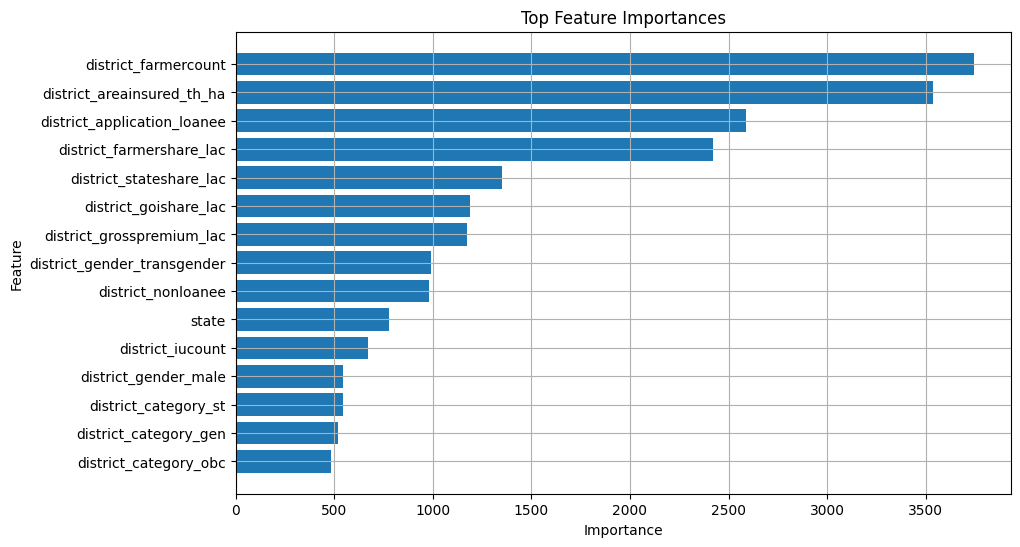

In [5]:
# Feature importance
importances = model.feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot importance
plt.figure(figsize=(10,6))
plt.barh(imp_df["feature"][:15][::-1], imp_df["importance"][:15][::-1])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid()
plt.show()


🔝 Top Features:
district_areainsured_th_ha: 28075.425 (↑ increases)
district_stateshare_lac: -3742.4993 (↓ decreases)
district_farmercount: -2007.3831 (↓ decreases)
district_goishare_lac: -1870.7658 (↓ decreases)
season: -1271.5261 (↓ decreases)

📊 Modality Scores: {'Financial': 0.22, 'Demographic': 0.042, 'Farming': 0.738}


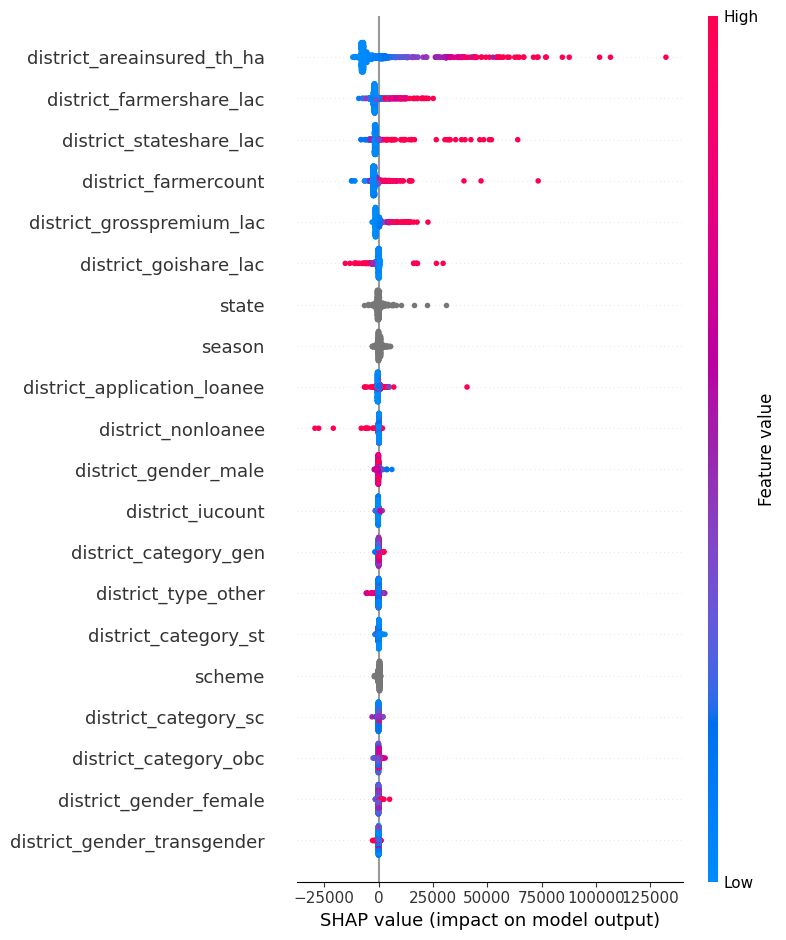

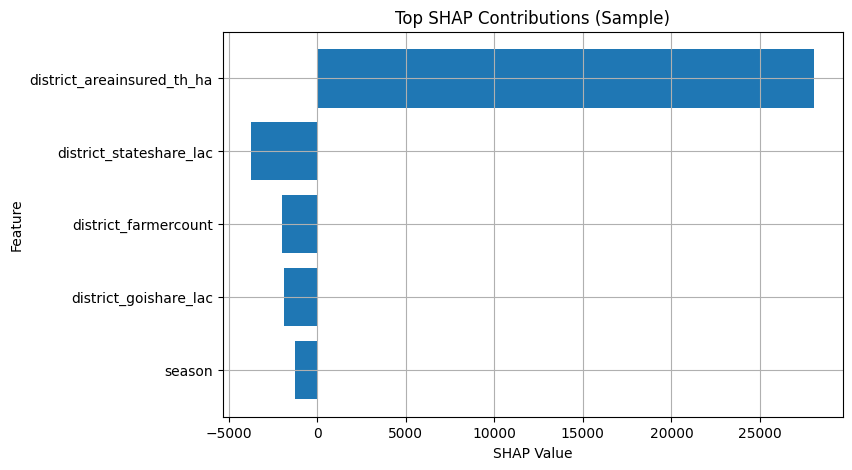

In [6]:
# ---------------- SHAP ----------------
explainer = shap.TreeExplainer(model)

# For LightGBM regressor → direct array
shap_values = explainer.shap_values(X_val)

# Pick one sample
sample = X_val.iloc[[0]]

shap_sample = explainer.shap_values(sample)[0]
feature_names = sample.columns.tolist()

shap_dict = dict(zip(feature_names, shap_sample))

# ---------------- TOP FEATURES ----------------
top_features = sorted(
    shap_dict.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:5]

print("\n🔝 Top Features:")
for f, v in top_features:
    direction = "↑ increases" if v > 0 else "↓ decreases"
    print(f"{f}: {round(v,4)} ({direction})")


# ---------------- MODALITY GROUPING (AUTO SAFE) ----------------

# Dynamically map features based on keywords (no hardcoding errors)
financial = [f for f in feature_names if any(k in f for k in ["share", "premium"])]
demographic = [f for f in feature_names if any(k in f for k in ["gender", "category"])]
farming = [f for f in feature_names if any(k in f for k in ["farmer", "area", "loanee"])]

def modality_score(group):
    if len(group) == 0:
        return 0
    return float(np.mean([abs(shap_dict.get(f, 0)) for f in group]))

modality_scores = {
    "Financial": modality_score(financial),
    "Demographic": modality_score(demographic),
    "Farming": modality_score(farming)
}

# Normalize
total = sum(modality_scores.values()) + 1e-8
modality_scores = {k: round(v/total, 3) for k,v in modality_scores.items()}

print("\n📊 Modality Scores:", modality_scores)


# ---------------- PLOTS ----------------

# 1. SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_val)

# 2. Bar plot for top features
top_df = sorted(top_features, key=lambda x: abs(x[1]))

plt.figure(figsize=(8,5))
plt.barh(
    [x[0] for x in top_df],
    [x[1] for x in top_df]
)
plt.title("Top SHAP Contributions (Sample)")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.grid()
plt.show()

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import os

df = pd.read_csv("PMFBY statistics.csv")

df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.replace("__", "_")
    .str.strip("_")
)

print("Columns:", df.columns.tolist())

drop_cols = ["district_updatedat", "district_nextlevelparams", "district_districtcode", "district_scheme"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

target = "district_suminsured_lac"

df = df.dropna()

print("Shape:", df.shape)

Columns: ['year', 'season', 'scheme', 'state', 'district_farmercount', 'district_application_loanee', 'district_nonloanee', 'district_areainsured_th_ha', 'district_suminsured_lac', 'district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_gender_male', 'district_gender_female', 'district_gender_transgender', 'district_category_sc', 'district_category_st', 'district_category_obc', 'district_category_gen', 'district_type_marginal', 'district_type_small', 'district_type_other', 'district_iucount', 'district_updatedat', 'district_districtname', 'district_districtcode', 'district_scheme', 'district_grosspremium_lac', 'district_nextlevelparams']
Shape: (3570, 25)


In [20]:
target = "district_suminsured_lac"

# Feature selection
features = [c for c in df.columns if c != target]
features = [c for c in features if not any(k in c for k in ["date", "code", "id"])]

df = df[features + [target]].copy()

# categorical handling
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype("category")

print("Categorical Columns:", cat_cols)

# Split data
X = df.drop(columns=[target])
y = df[target]

# 🔥 FIRST split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 🔥 SECOND split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("\nShapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Categorical Columns: ['season', 'scheme', 'state', 'district_districtname']

Shapes:
Train: (2427, 24)
Val: (607, 24)
Test: (536, 24)


In [14]:
n_cores = os.cpu_count()
use_cores = max(1, n_cores - 2)

model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=use_cores
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(100)]
)

# Predictions
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("\n📊 PERFORMANCE")
print("Train R2:", r2_score(y_train, train_pred))
print("Val R2:", r2_score(y_val, val_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Val RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5107
[LightGBM] [Info] Number of data points in the train set: 2427, number of used features: 24
[LightGBM] [Info] Start training from score 15071.830515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes


Top Features:
                         feature  importance
8      district_farmershare_lac         558
7    district_areainsured_th_ha         544
4          district_farmercount         334
23    district_grosspremium_lac         166
10      district_stateshare_lac         138
3                         state         133
5   district_application_loanee         132
17        district_category_gen         109
11         district_gender_male         100
21             district_iucount          96


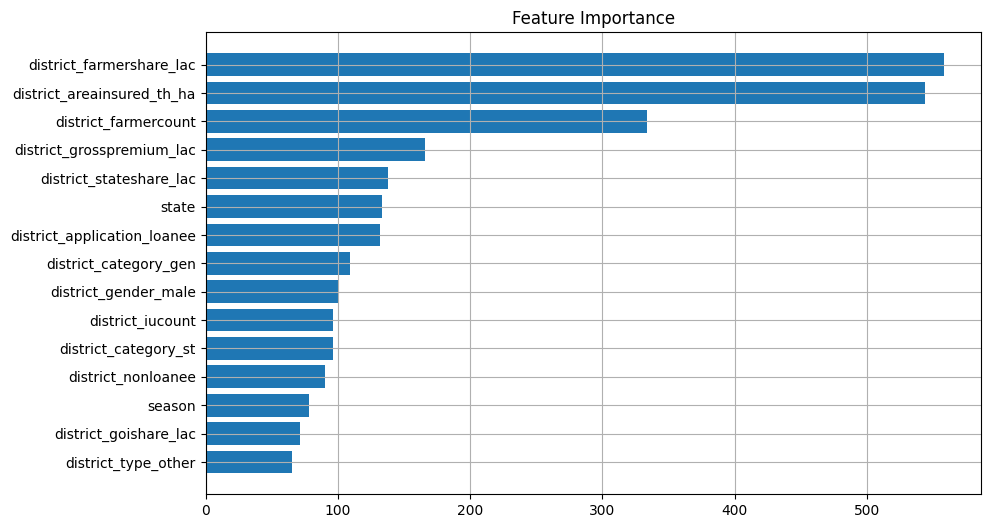

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5103
[LightGBM] [Info] Number of data points in the train set: 2427, number of used features: 23
[LightGBM] [Info] Start training from score 15071.830515
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51

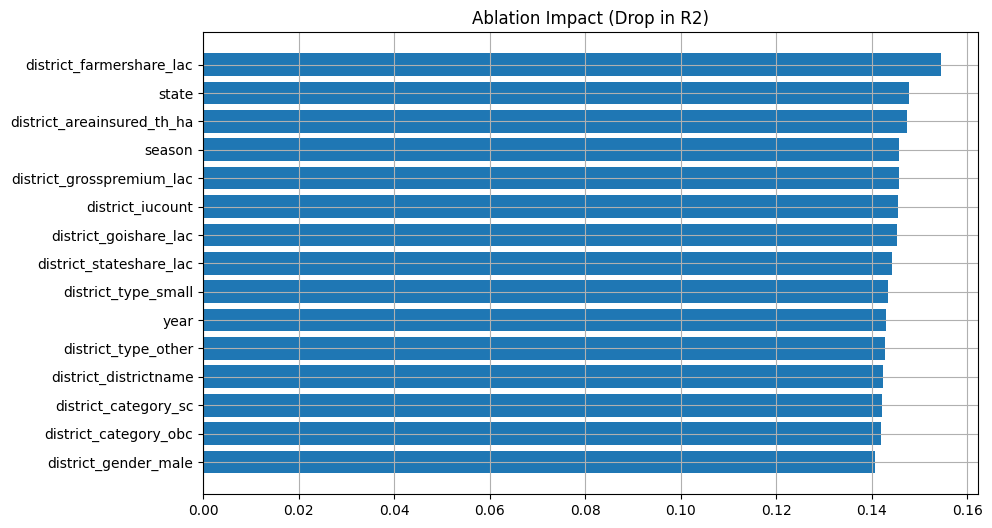

In [15]:
# -------- Feature Importance --------
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Features:\n", imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(imp["feature"][:15][::-1], imp["importance"][:15][::-1])
plt.title("Feature Importance")
plt.grid()
plt.show()


# -------- ABLATION STUDY --------
baseline_r2 = r2_score(y_val, val_pred)

ablation_results = []

for col in X.columns:
    X_train_drop = X_train.drop(columns=[col])
    X_val_drop = X_val.drop(columns=[col])

    temp_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=use_cores)
    temp_model.fit(X_train_drop, y_train)

    pred = temp_model.predict(X_val_drop)
    score = r2_score(y_val, pred)

    impact = baseline_r2 - score
    ablation_results.append((col, impact))

ablation_df = pd.DataFrame(ablation_results, columns=["feature", "impact"]).sort_values(by="impact", ascending=False)

print("\n🔬 Ablation Impact:\n", ablation_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(ablation_df["feature"][:15][::-1], ablation_df["impact"][:15][::-1])
plt.title("Ablation Impact (Drop in R2)")
plt.grid()
plt.show()


🔝 Top SHAP Features:
district_areainsured_th_ha: 55715.3314
district_stateshare_lac: 20940.153
district_farmershare_lac: 17818.9316
district_grosspremium_lac: 13361.8752
district_farmercount: 4215.0467

📊 Modality Scores: {'Financial': 0.455, 'Demographic': 0.012, 'Farming': 0.533}


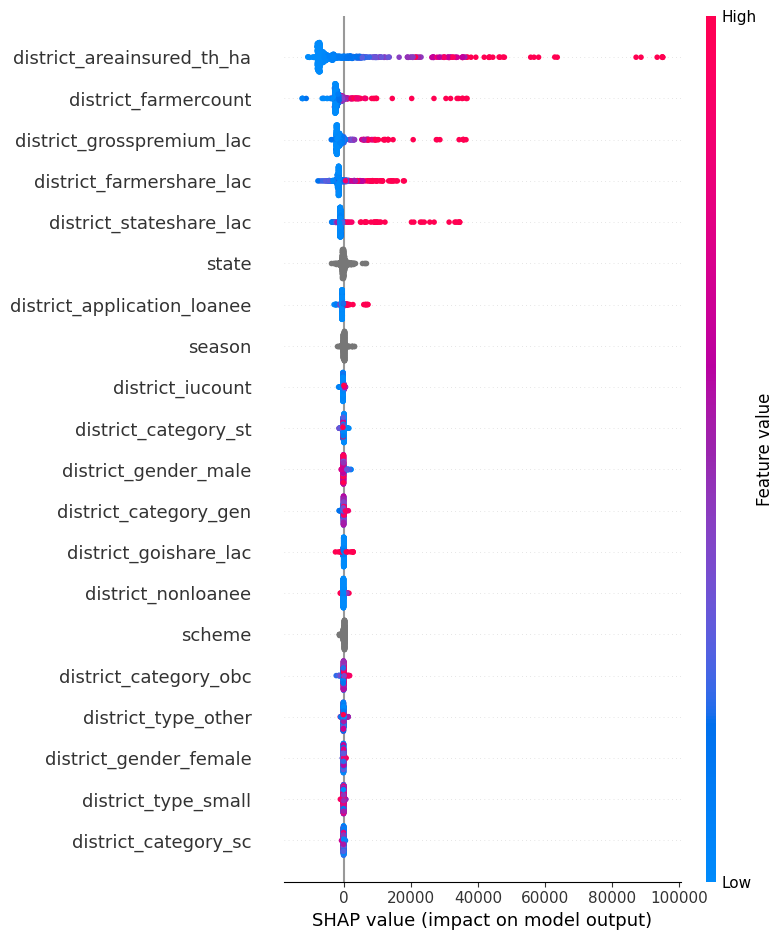

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

sample = X_val.iloc[[0]]
shap_sample = explainer.shap_values(sample)[0]

shap_dict = dict(zip(sample.columns, shap_sample))

# Top features
top_features = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

print("\n🔝 Top SHAP Features:")
for f, v in top_features:
    print(f"{f}: {round(v,4)}")


# -------- Modality grouping --------
financial = [f for f in sample.columns if "share" in f or "premium" in f]
demographic = [f for f in sample.columns if "gender" in f or "category" in f]
farming = [f for f in sample.columns if "farmer" in f or "area" in f or "loanee" in f]

def mod_score(group):
    return np.mean([abs(shap_dict.get(f, 0)) for f in group]) if group else 0

mods = {
    "Financial": mod_score(financial),
    "Demographic": mod_score(demographic),
    "Farming": mod_score(farming)
}

total = sum(mods.values()) + 1e-8
mods = {k: round(v/total, 3) for k,v in mods.items()}

print("\n📊 Modality Scores:", mods)

# SHAP plot
shap.summary_plot(shap_values, X_val)

In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import os

df = pd.read_csv("PMFBY statistics.csv")

df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.replace("__", "_")
    .str.strip("_")
)

print("Columns:", df.columns.tolist())

# Drop useless columns
drop_cols = [
    "district_updatedat",
    "district_nextlevelparams",
    "district_districtcode",
    "district_scheme"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Target
target = "district_suminsured_lac"

# Drop NA
df = df.dropna()

print("Shape:", df.shape)

Columns: ['year', 'season', 'scheme', 'state', 'district_farmercount', 'district_application_loanee', 'district_nonloanee', 'district_areainsured_th_ha', 'district_suminsured_lac', 'district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_gender_male', 'district_gender_female', 'district_gender_transgender', 'district_category_sc', 'district_category_st', 'district_category_obc', 'district_category_gen', 'district_type_marginal', 'district_type_small', 'district_type_other', 'district_iucount', 'district_updatedat', 'district_districtname', 'district_districtcode', 'district_scheme', 'district_grosspremium_lac', 'district_nextlevelparams']
Shape: (3570, 25)


In [23]:
target = "district_suminsured_lac"

# ❌ REMOVE LEAKAGE FEATURES
leak_cols = [
    "district_farmershare_lac",
    "district_goishare_lac",
    "district_stateshare_lac",
    "district_grosspremium_lac"
]

# Base features
features = [c for c in df.columns if c != target]
features = [c for c in features if not any(k in c for k in ["date", "code", "id"])]

# Remove leakage
features = [c for c in features if c not in leak_cols]

print("🚫 Removed leakage:", leak_cols)

df = df[features + [target]].copy()

# categorical
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype("category")

print("Categorical Columns:", cat_cols)

# Split
X = df.drop(columns=[target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("\nShapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

🚫 Removed leakage: ['district_farmershare_lac', 'district_goishare_lac', 'district_stateshare_lac', 'district_grosspremium_lac']
Categorical Columns: []

Shapes:
Train: (2427, 20)
Val: (607, 20)
Test: (536, 20)


In [24]:
n_cores = os.cpu_count()
use_cores = max(1, n_cores - 2)

model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=use_cores
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(100)]
)

# Predictions
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("\n📊 PERFORMANCE (NO LEAKAGE MODEL)")
print("Train R2:", r2_score(y_train, train_pred))
print("Val R2:", r2_score(y_val, val_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Val RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000898 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4087
[LightGBM] [Info] Number of data points in the train set: 2427, number of used features: 20
[LightGBM] [Info] Start training from score 15071.830515
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes


Top Features:
                         feature  importance
7    district_areainsured_th_ha         777
4          district_farmercount         515
5   district_application_loanee         239
3                         state         164
8          district_gender_male         159
12         district_category_st         138
6            district_nonloanee         130
18             district_iucount         128
14        district_category_gen         114
17          district_type_other         102


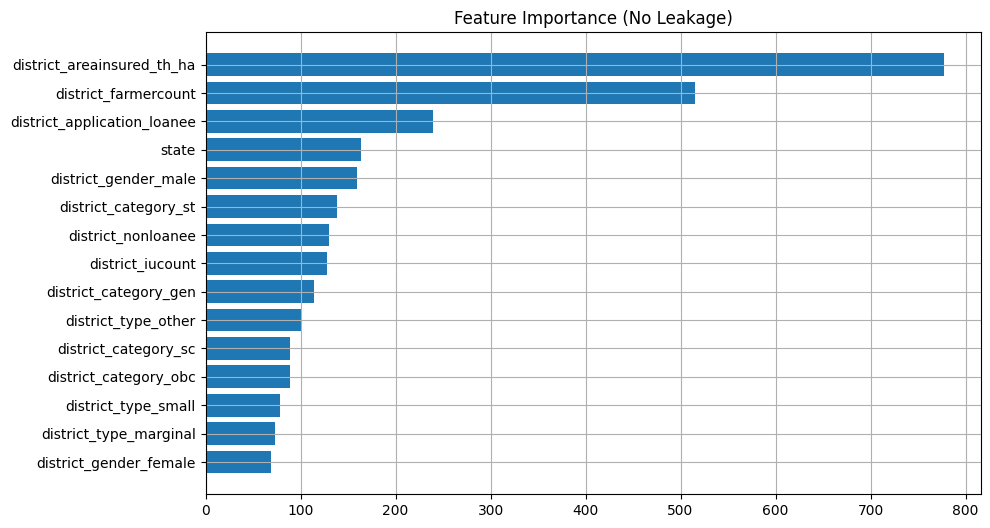

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4083
[LightGBM] [Info] Number of data points in the train set: 2427, number of used features: 19
[LightGBM] [Info] Start training from score 15071.830515
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40

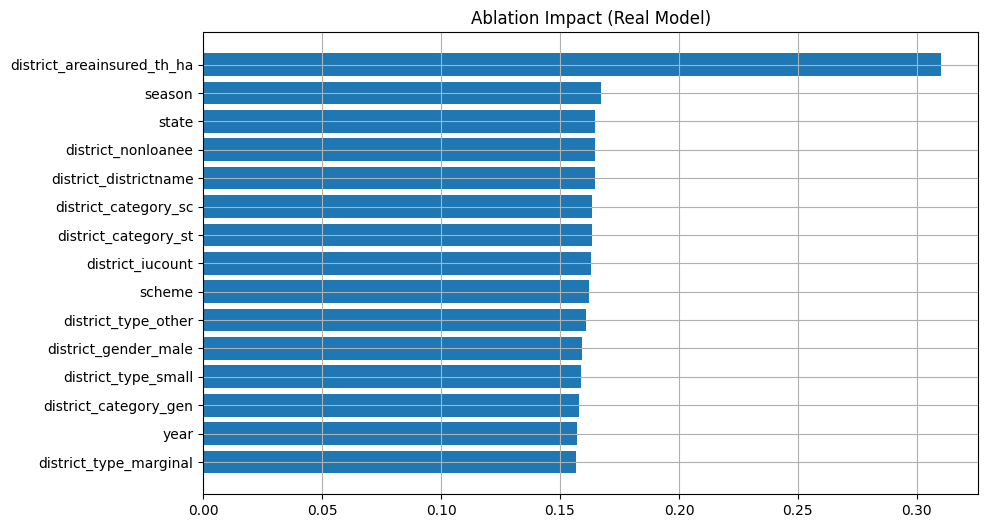

In [25]:
# -------- Feature Importance --------
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Features:\n", imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(imp["feature"][:15][::-1], imp["importance"][:15][::-1])
plt.title("Feature Importance (No Leakage)")
plt.grid()
plt.show()


# -------- ABLATION --------
baseline_r2 = r2_score(y_val, val_pred)

ablation_results = []

for col in X.columns:
    X_train_drop = X_train.drop(columns=[col])
    X_val_drop = X_val.drop(columns=[col])

    temp_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=use_cores
    )
    temp_model.fit(X_train_drop, y_train)

    pred = temp_model.predict(X_val_drop)
    score = r2_score(y_val, pred)

    impact = baseline_r2 - score
    ablation_results.append((col, impact))

ablation_df = pd.DataFrame(ablation_results, columns=["feature", "impact"]).sort_values(by="impact", ascending=False)

print("\n🔬 Ablation Impact:\n", ablation_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(ablation_df["feature"][:15][::-1], ablation_df["impact"][:15][::-1])
plt.title("Ablation Impact (Real Model)")
plt.grid()
plt.show()


🔝 Top SHAP Features:
district_areainsured_th_ha: 63666.4789
district_farmercount: 16952.3905
district_application_loanee: 6994.8343
district_category_st: 5921.7269
district_type_other: 2299.5584

📊 Modality Scores: {'Financial': 0.0, 'Demographic': 0.061, 'Farming': 0.939}


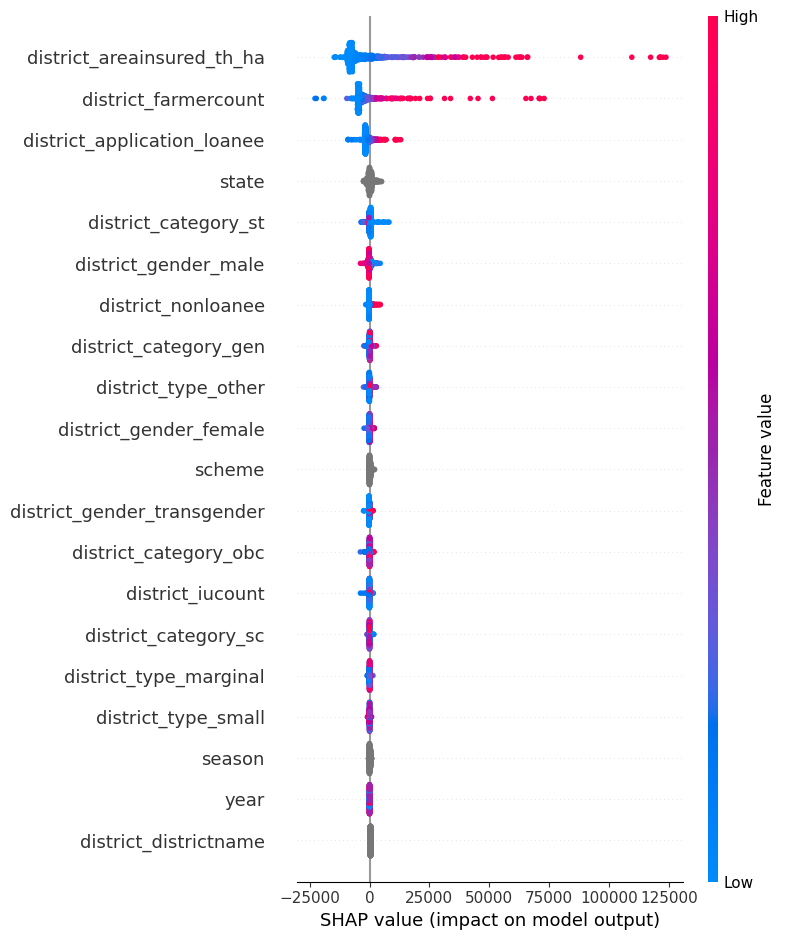

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

sample = X_val.iloc[[0]]
shap_sample = explainer.shap_values(sample)[0]

shap_dict = dict(zip(sample.columns, shap_sample))

# Top features
top_features = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

print("\n🔝 Top SHAP Features:")
for f, v in top_features:
    print(f"{f}: {round(v,4)}")


# -------- Modality grouping --------
financial = [f for f in sample.columns if "share" in f or "premium" in f]
demographic = [f for f in sample.columns if "gender" in f or "category" in f]
farming = [f for f in sample.columns if "farmer" in f or "area" in f or "loanee" in f]

def mod_score(group):
    return np.mean([abs(shap_dict.get(f, 0)) for f in group]) if group else 0

mods = {
    "Financial": mod_score(financial),
    "Demographic": mod_score(demographic),
    "Farming": mod_score(farming)
}

total = sum(mods.values()) + 1e-8
mods = {k: round(v/total, 3) for k,v in mods.items()}

print("\n📊 Modality Scores:", mods)

shap.summary_plot(shap_values, X_val)

In [27]:
import pickle
import lightgbm as lgb

# ---------- SAVE AS LIGHTGBM TXT ----------
model.booster_.save_model("agro_model.txt")
print("✅ Saved LightGBM model as agro_model.txt")

# ---------- SAVE AS PICKLE ----------
with open("agro_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Saved model as agro_model.pkl")

✅ Saved LightGBM model as agro_model.txt
✅ Saved model as agro_model.pkl


In [40]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import os

df = pd.read_csv("PMFBY coverage.csv")

# Clean columns
df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.replace("__", "_")
    .str.strip("_")
)

print("Columns:\n", df.columns.tolist())

# 🔥 DO NOT DROP ALL NA
# Instead: only drop rows where target is missing

# Detect target
target_cols = [c for c in df.columns if "suminsured" in c]
target = target_cols[0]

df = df.dropna(subset=[target])

print("Shape after fixing NA:", df.shape)

Columns:
 ['sssyname_year', 'sssyname_seasonname', 'sssyname_schemename', 'sssyname_statename', 'level3name', 'cropname', 'suminsured', 'premiumrate', 'stateshare', 'goishare', 'sssyid', 'seasonid', 'seasoncode', 'schemeid', 'schemecode', 'stateid', 'statecode', 'year', 'startdate', 'enddate', 'policystartdate', 'policyenddate', 'isopen', 'cnstarted', 'cniscopied', 'policy', 'notification', 'ispreviousseasonyearinsubsidy', 'isofflinechallan', 'firstgoisubsidy', 'goiofflinechallan', 'stateofflinechallan', 'ayty', 'yieldenddate', 'currenttime', 'default', 'level3id', 'level3', 'level3code', 'cropid', 'cropcode', 'pickingtype', 'categoryname', 'croptype', 'type', 'unit', 'croptypecode', 'indemnitylevel', 'farmershare', 'farmersharevalue', 'goisharevalue', 'statesharevalue', 'insurancecompanyname', 'cutofdate', 'tollfreenumber', 'headquateraddress', 'headquateremail', 'websitelink', 'sssyname_schemenameshort', 'insurancecompany_insurancecompanyid', 'insurancecompany_insurancecompanycode', 

In [41]:
# 🔍 DEBUG: check columns
print("\nAvailable columns:\n", df.columns.tolist())

# 🔥 Find correct target automatically
possible_targets = [c for c in df.columns if "suminsured" in c]

if len(possible_targets) == 0:
    raise ValueError("❌ No target column found")

target = possible_targets[0]
print("\n🎯 Using target:", target)


# -----------------------------
# 🚨 REMOVE LEAKAGE FEATURES
# -----------------------------
leak_keywords = [
    "farmersharevalue",
    "goisharevalue",
    "statesharevalue"
]

remove_cols = [
    "level3name",              # 🚨 district ID proxy
    "insurancecompanyname",    # 🚨 indirect leakage
    "stateshare",              # 🚨 derived
    "goishare",
    "farmershare"
]

junk_keywords = [
    "id", "code", "address", "email", "website",
    "date", "time", "number"
]


# -----------------------------
# 🔥 SAFE FEATURE SELECTION
# -----------------------------
features = []

for col in df.columns:
    if col == target:
        continue
    
    # remove exact leakage cols
    if col in remove_cols:
        continue
    
    # remove keyword-based leakage
    if any(k in col for k in leak_keywords):
        continue
    
    # remove junk/meta columns
    if any(k in col for k in junk_keywords):
        continue

    features.append(col)


print("\n✅ Selected features:\n", features)


# -----------------------------
# 📦 FINAL DATAFRAME
# -----------------------------
df = df[features + [target]].copy()

print("\nShape after filtering:", df.shape)

if df.shape[0] == 0:
    raise ValueError("❌ Data became empty — check filtering logic")


# -----------------------------
# 🔤 CATEGORICAL HANDLING
# -----------------------------
cat_cols = df.select_dtypes(include="object").columns.tolist()

for c in cat_cols:
    df[c] = df[c].astype("category")

print("\n📊 Categorical columns:", cat_cols)


# -----------------------------
# 🔀 TRAIN / VAL / TEST SPLIT
# -----------------------------
X = df.drop(columns=[target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("\n✅ Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Available columns:
 ['sssyname_year', 'sssyname_seasonname', 'sssyname_schemename', 'sssyname_statename', 'level3name', 'cropname', 'suminsured', 'premiumrate', 'stateshare', 'goishare', 'sssyid', 'seasonid', 'seasoncode', 'schemeid', 'schemecode', 'stateid', 'statecode', 'year', 'startdate', 'enddate', 'policystartdate', 'policyenddate', 'isopen', 'cnstarted', 'cniscopied', 'policy', 'notification', 'ispreviousseasonyearinsubsidy', 'isofflinechallan', 'firstgoisubsidy', 'goiofflinechallan', 'stateofflinechallan', 'ayty', 'yieldenddate', 'currenttime', 'default', 'level3id', 'level3', 'level3code', 'cropid', 'cropcode', 'pickingtype', 'categoryname', 'croptype', 'type', 'unit', 'croptypecode', 'indemnitylevel', 'farmershare', 'farmersharevalue', 'goisharevalue', 'statesharevalue', 'insurancecompanyname', 'cutofdate', 'tollfreenumber', 'headquateraddress', 'headquateremail', 'websitelink', 'sssyname_schemenameshort', 'insurancecompany_insurancecompanyid', 'insurancecompany_insurancecom

In [42]:
n_cores = os.cpu_count()
use_cores = max(1, n_cores - 2)

model = lgb.LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.02,
    max_depth=7,
    num_leaves=50,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=use_cores,
    force_col_wise=True
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(150)]
)

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("\n📊 PERFORMANCE (Policy Model)")
print("Train R2:", r2_score(y_train, train_pred))
print("Val R2:", r2_score(y_val, val_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Val RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 20399, number of used features: 21
[LightGBM] [Info] Start training from score 59852.414905
Training until validation scores don't improve for 150 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh


Top Features:
                                   feature  importance
5                             premiumrate       39144
4                                cropname       17666
0                           sssyname_year       13698
3                      sssyname_statename       12141
25  insurancecompany_insurancecompanyname        7703
23                         indemnitylevel        6444
1                     sssyname_seasonname        4443
19                           categoryname        4233
15                                   ayty        2383
7                                  isopen        2346


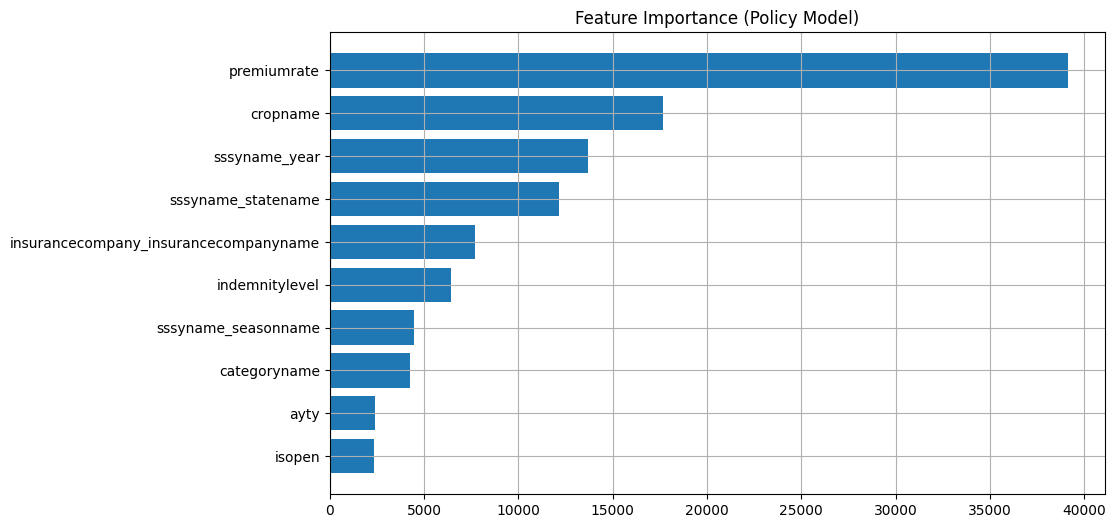

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 591
[LightGBM] [Info] Number of data points in the train set: 20399, number of used features: 20
[LightGBM] [Info] Start training from score 59852.414905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 20399, number of used features: 20
[LightGBM] [Info] Start training from score 59852.414905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

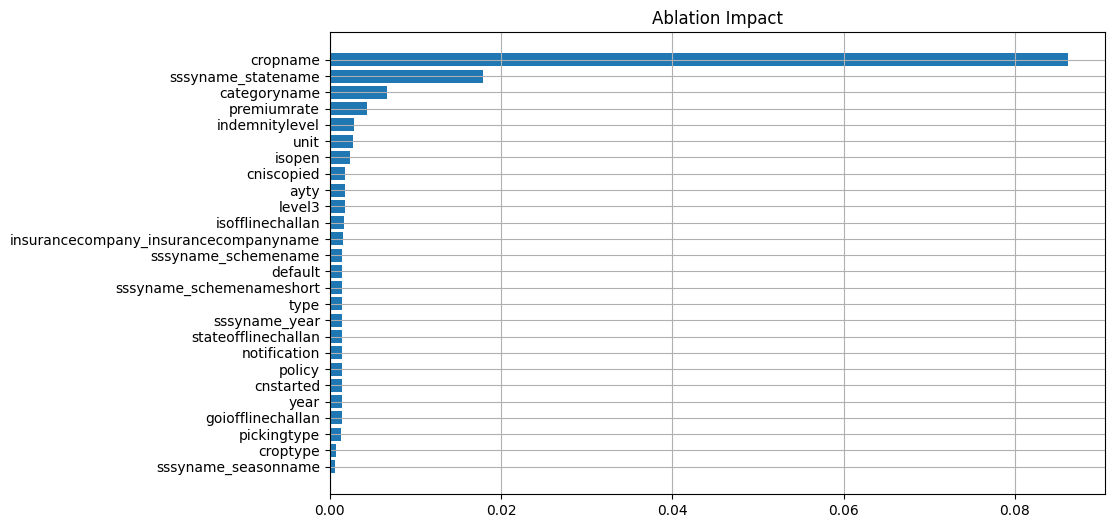

In [43]:
# Feature importance
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Features:\n", imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(imp["feature"][:10][::-1], imp["importance"][:10][::-1])
plt.title("Feature Importance (Policy Model)")
plt.grid()
plt.show()


# Ablation
baseline_r2 = r2_score(y_val, val_pred)

results = []
for col in X.columns:
    X_train_d = X_train.drop(columns=[col])
    X_val_d = X_val.drop(columns=[col])

    temp_model = lgb.LGBMRegressor(n_estimators=1000, n_jobs=use_cores)
    temp_model.fit(X_train_d, y_train)

    pred = temp_model.predict(X_val_d)
    score = r2_score(y_val, pred)

    results.append((col, baseline_r2 - score))

ablation_df = pd.DataFrame(results, columns=["feature", "impact"]).sort_values(by="impact", ascending=False)

print("\n🔬 Ablation:\n", ablation_df)

plt.figure(figsize=(10,6))
plt.barh(ablation_df["feature"][::-1], ablation_df["impact"][::-1])
plt.title("Ablation Impact")
plt.grid()
plt.show()


🔝 Top SHAP Features:
cropname: 53595.1671
sssyname_statename: 22824.482
categoryname: 7088.5017
sssyname_year: -4359.7425
indemnitylevel: 3378.6483

📊 Modality: {'Policy': 0.07, 'Geography': 0.251, 'Crop': 0.679}


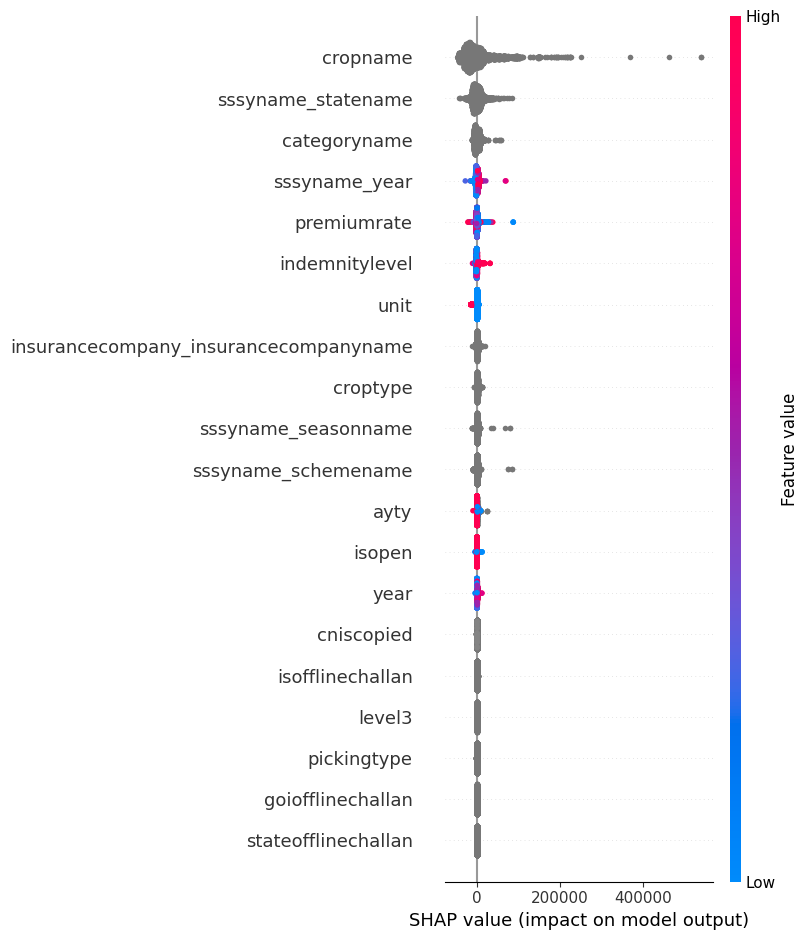

In [44]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

sample = X_val.iloc[[0]]
shap_sample = explainer.shap_values(sample)[0]

shap_dict = dict(zip(sample.columns, shap_sample))

top = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

print("\n🔝 Top SHAP Features:")
for f, v in top:
    print(f"{f}: {round(v,4)}")


# modality
policy = [f for f in sample.columns if "premium" in f or "indemnity" in f]
geo = [f for f in sample.columns if "state" in f or "level3" in f]
crop = [f for f in sample.columns if "crop" in f or "category" in f]

def score(g):
    return np.mean([abs(shap_dict.get(f,0)) for f in g]) if g else 0

mods = {
    "Policy": score(policy),
    "Geography": score(geo),
    "Crop": score(crop)
}

total = sum(mods.values()) + 1e-8
mods = {k: round(v/total,3) for k,v in mods.items()}

print("\n📊 Modality:", mods)

shap.summary_plot(shap_values, X_val)

In [45]:
import pickle
import json
import lightgbm as lgb

# -------------------------
# 📦 1. SAVE AS PICKLE (.pkl)
# -------------------------
with open("policy_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Saved: policy_model.pkl")


# -------------------------
# 📦 2. SAVE AS LIGHTGBM TXT
# -------------------------
model.booster_.save_model("policy_model.txt")

print("✅ Saved: policy_model.txt")


# -------------------------
# 📦 3. SAVE FEATURE LIST (VERY IMPORTANT)
# -------------------------
feature_info = {
    "features": X.columns.tolist(),
    "categorical_features": cat_cols,
    "target": target
}

with open("policy_model_features.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("✅ Saved: policy_model_features.json")


# -------------------------
# 📦 4. (OPTIONAL) SAVE BEST ITERATION
# -------------------------
meta = {
    "best_iteration": int(model.best_iteration_),
    "n_features": len(X.columns)
}

with open("policy_model_meta.json", "w") as f:
    json.dump(meta, f, indent=4)

print("✅ Saved: policy_model_meta.json")

✅ Saved: policy_model.pkl
✅ Saved: policy_model.txt
✅ Saved: policy_model_features.json
✅ Saved: policy_model_meta.json
